# Minnesota MVP: Access & BEI Plots

This notebook explores the Minnesota-only access and BEI outputs.

**Inputs (MN-only):**
- `Data/output/tables/mn_tract_access.parquet`
- `Data/output/tables/mn_tract_bei.parquet`

Make sure you've run:

```bash
cd src
python -m pipeline.mn_mvp_pipeline
```

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

# Detect repo root robustly when running from src/notebooks or project root
REPO_ROOT = Path(os.getcwd()).resolve()

# Case 1: running from project root (has src/ and Data/)
if (REPO_ROOT / "src").is_dir() and (REPO_ROOT / "Data").is_dir():
    pass
# Case 2: running from src/ (has notebooks/ sibling and Data/ one level up)
elif (REPO_ROOT.name == "src") and (REPO_ROOT.parent / "Data").is_dir():
    REPO_ROOT = REPO_ROOT.parent
# Case 3: running from src/notebooks (common in VS Code / Jupyter)
elif (REPO_ROOT.name == "notebooks") and (REPO_ROOT.parent.parent / "Data").is_dir():
    REPO_ROOT = REPO_ROOT.parent.parent

DATA_TABLES = REPO_ROOT / "Data" / "output" / "tables"
FIG_DIR = REPO_ROOT / "Data" / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ACCESS_PATH = DATA_TABLES / "mn_tract_access.parquet"
BEI_PATH = DATA_TABLES / "mn_tract_bei.parquet"

ACCESS_PATH, BEI_PATH, FIG_DIR

(WindowsPath('C:/Users/tngzj/OneDrive/Desktop/Heatmap_Hackathon/Data/output/tables/mn_tract_access.parquet'),
 WindowsPath('C:/Users/tngzj/OneDrive/Desktop/Heatmap_Hackathon/Data/output/tables/mn_tract_bei.parquet'),
 WindowsPath('C:/Users/tngzj/OneDrive/Desktop/Heatmap_Hackathon/Data/output/figures'))

In [13]:
access = pd.read_parquet(ACCESS_PATH)
bei = pd.read_parquet(BEI_PATH)

print("Access shape:", access.shape)
print("BEI shape:", bei.shape)

# Merge BEI columns onto access
mn = access.merge(
    bei[["GEOID", "bei", "bei_percentile", "t_score"]],
    on="GEOID",
    how="left",
)

print("Merged shape:", mn.shape)
mn.head()

Access shape: (1505, 26)
BEI shape: (1505, 32)
Merged shape: (1505, 29)


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,is_rural,t_dir,t_stab,t_trans,t_sys,t_delta,access_pathway,bei,bei_percentile,t_score
0,27,137,013400,27137013400,1400000US27137013400,134,Census Tract 134,G5020,S,169899935,...,True,62.300000,61.800000,169.100000,62.300000,31.80,direct,8.323229,62.259136,0.277441
1,27,137,002000,27137002000,1400000US27137002000,20,Census Tract 20,G5020,S,1122627,...,False,3.583333,3.583333,52.166667,3.583333,0.00,direct,0.000000,2.558140,0.000000
2,27,137,002200,27137002200,1400000US27137002200,22,Census Tract 22,G5020,S,2531157,...,False,8.383333,8.383333,61.766667,8.383333,0.00,direct,0.435935,11.760797,0.014531
3,27,137,002400,27137002400,1400000US27137002400,24,Census Tract 24,G5020,S,804998,...,False,4.950000,4.950000,54.900000,4.950000,0.00,direct,0.000000,2.558140,0.000000
4,27,095,970100,27095970100,1400000US27095970100,9701,Census Tract 9701,G5020,S,114035403,...,True,96.300000,88.450000,229.750000,96.300000,58.45,direct,13.296978,75.215947,0.443233


In [14]:
cols_of_interest = [
    "t_dir", "t_stab", "t_trans", "t_sys",
    "bei", "bei_percentile",
]
mn[cols_of_interest].describe()

,t_dir,t_stab,t_trans,t_sys,bei,bei_percentile
count,1505.000000,1505.000000,1505.000000,1505.000000,1505.000000,1505.000000
mean,64.426656,49.769114,159.195770,64.426656,8.234551,50.033223
std,70.389328,59.668536,128.442171,70.389328,9.075075,28.873379
min,1.150000,1.050000,47.300000,1.150000,0.000000,2.558140
25%,14.400000,11.383333,72.366667,14.400000,1.316093,25.116279
50%,29.950000,22.816667,101.866667,29.950000,3.590852,50.033223
75%,95.383333,67.016667,206.900000,95.383333,13.162882,75.016611
max,408.050000,381.050000,834.100000,408.050000,30.000000,97.508306


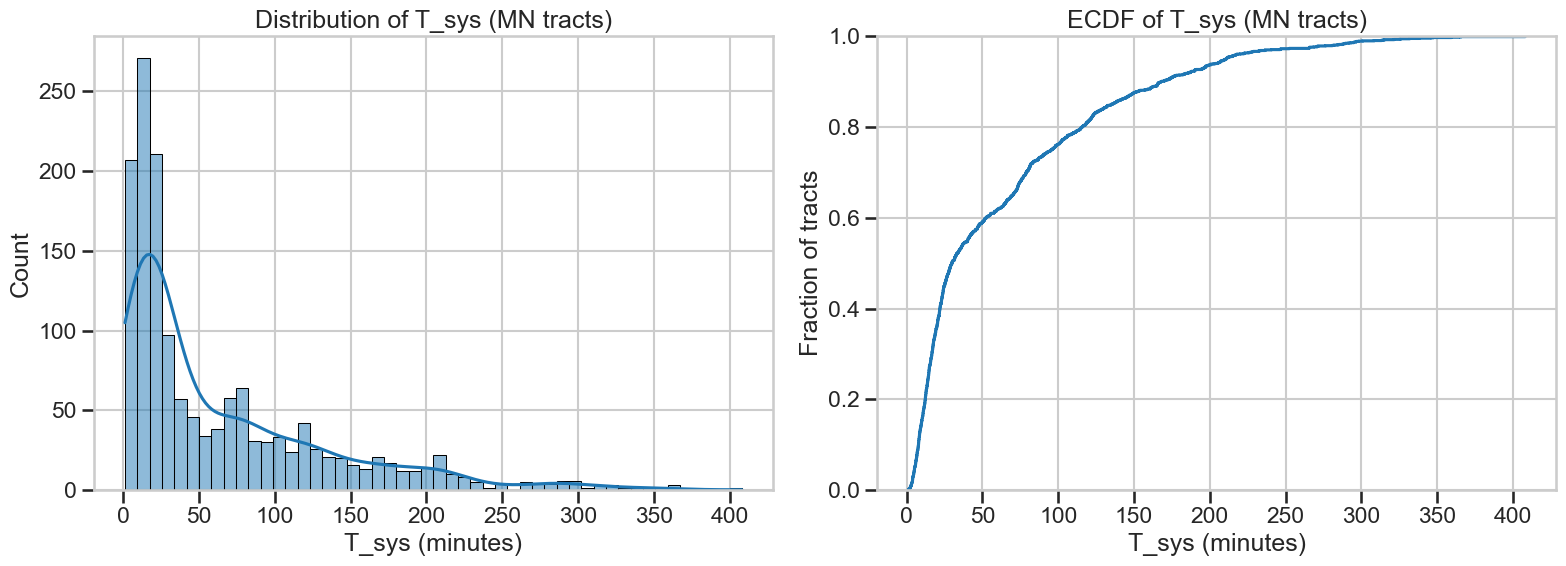

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=mn,
    x="t_sys",
    bins=50,
    kde=True,
    ax=ax[0],
    color="tab:blue",
)
ax[0].set_title("Distribution of T_sys (MN tracts)")
ax[0].set_xlabel("T_sys (minutes)")

sns.ecdfplot(
    data=mn,
    x="t_sys",
    ax=ax[1],
    color="tab:blue",
)
ax[1].set_title("ECDF of T_sys (MN tracts)")
ax[1].set_xlabel("T_sys (minutes)")
ax[1].set_ylabel("Fraction of tracts")

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / "mn_t_sys_distribution.png", dpi=200, bbox_inches="tight")

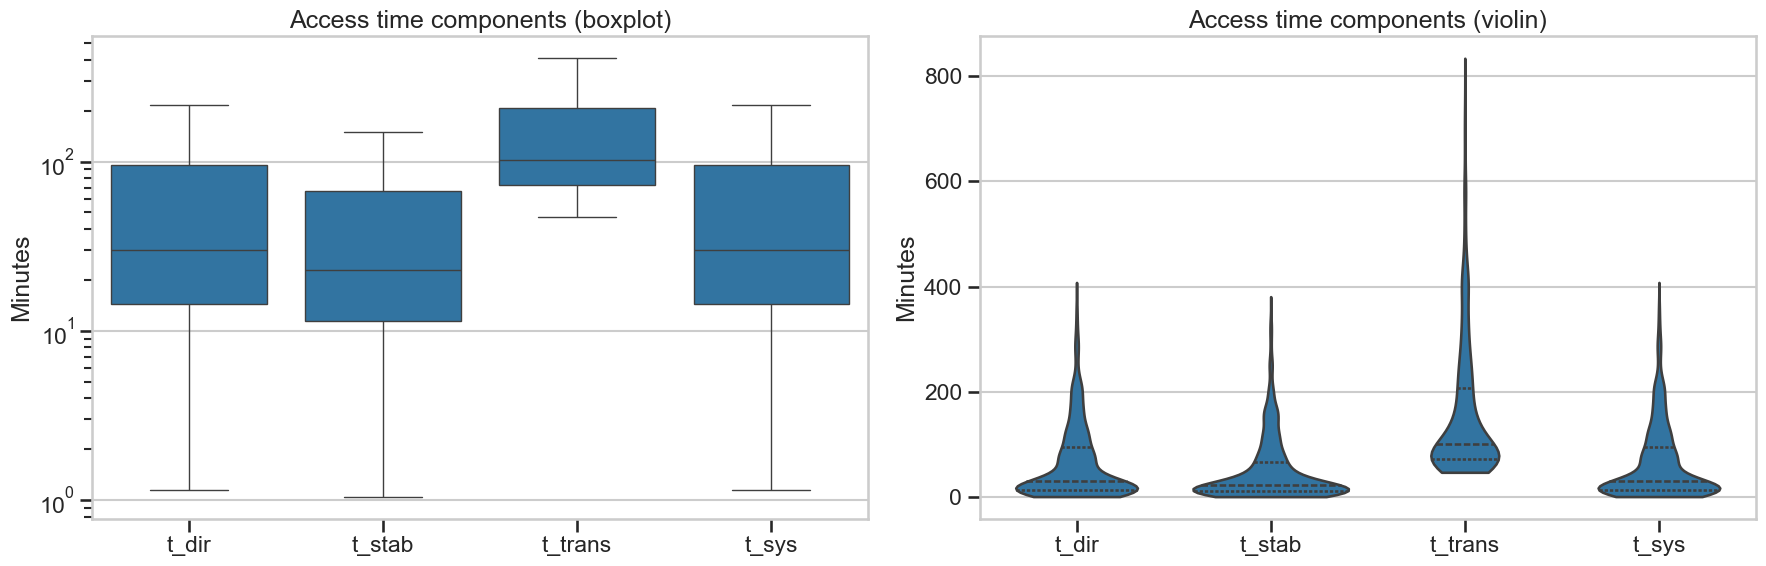

In [16]:
melt_cols = ["t_dir", "t_stab", "t_trans", "t_sys"]
mn_long = mn[melt_cols].melt(
    var_name="metric",
    value_name="minutes",
)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=mn_long,
    x="metric",
    y="minutes",
    showfliers=False,
    ax=ax[0],
)
ax[0].set_title("Access time components (boxplot)")
ax[0].set_xlabel("")
ax[0].set_ylabel("Minutes")
ax[0].set_yscale("log")  # helps with tail

sns.violinplot(
    data=mn_long,
    x="metric",
    y="minutes",
    inner="quartile",
    cut=0,
    ax=ax[1],
)
ax[1].set_title("Access time components (violin)")
ax[1].set_xlabel("")
ax[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / "mn_access_components.png", dpi=200, bbox_inches="tight")

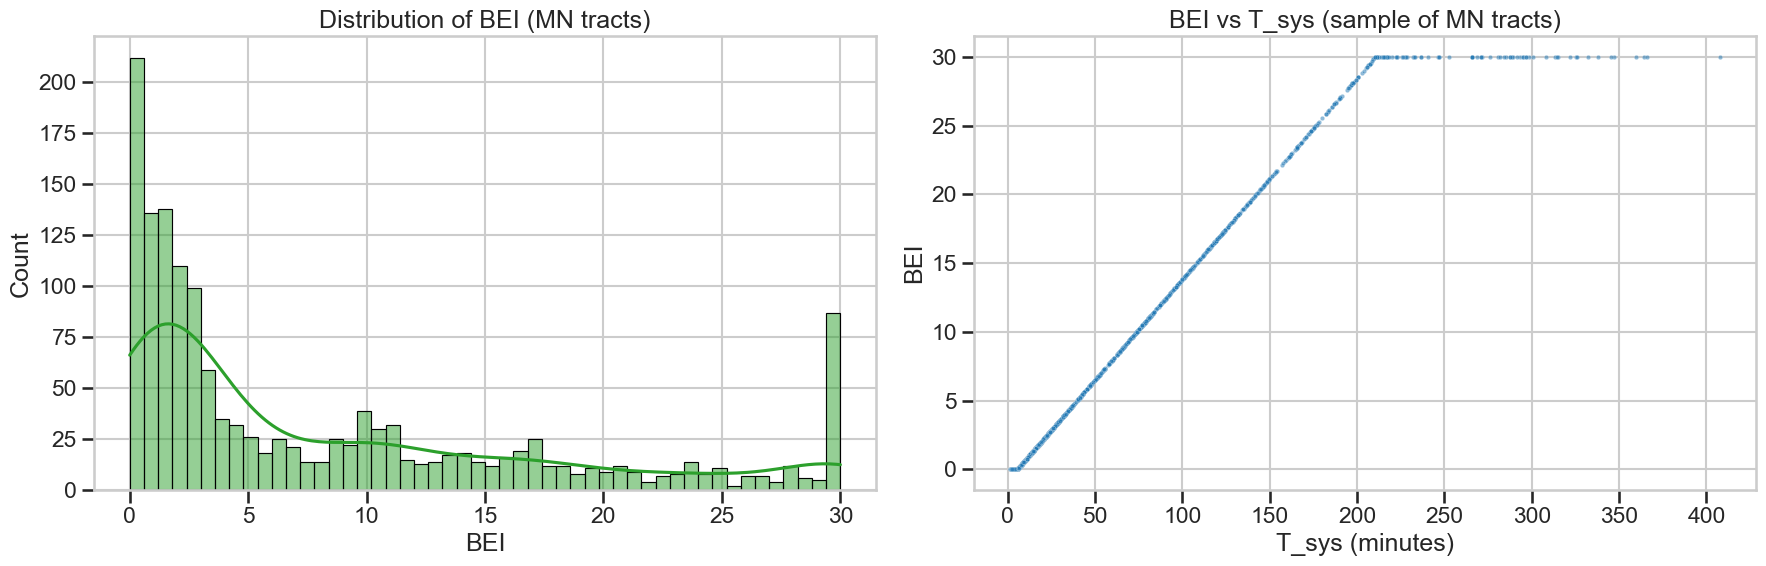

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(
    data=mn,
    x="bei",
    bins=50,
    kde=True,
    color="tab:green",
    ax=ax[0],
)
ax[0].set_title("Distribution of BEI (MN tracts)")
ax[0].set_xlabel("BEI")

sample = mn.sample(min(len(mn), 5000), random_state=42)
sns.scatterplot(
    data=sample,
    x="t_sys",
    y="bei",
    s=10,
    alpha=0.5,
    ax=ax[1],
)
ax[1].set_title("BEI vs T_sys (sample of MN tracts)")
ax[1].set_xlabel("T_sys (minutes)")
ax[1].set_ylabel("BEI")

plt.tight_layout()
plt.show()

fig.savefig(FIG_DIR / "mn_bei_distribution_and_scatter.png", dpi=200, bbox_inches="tight")

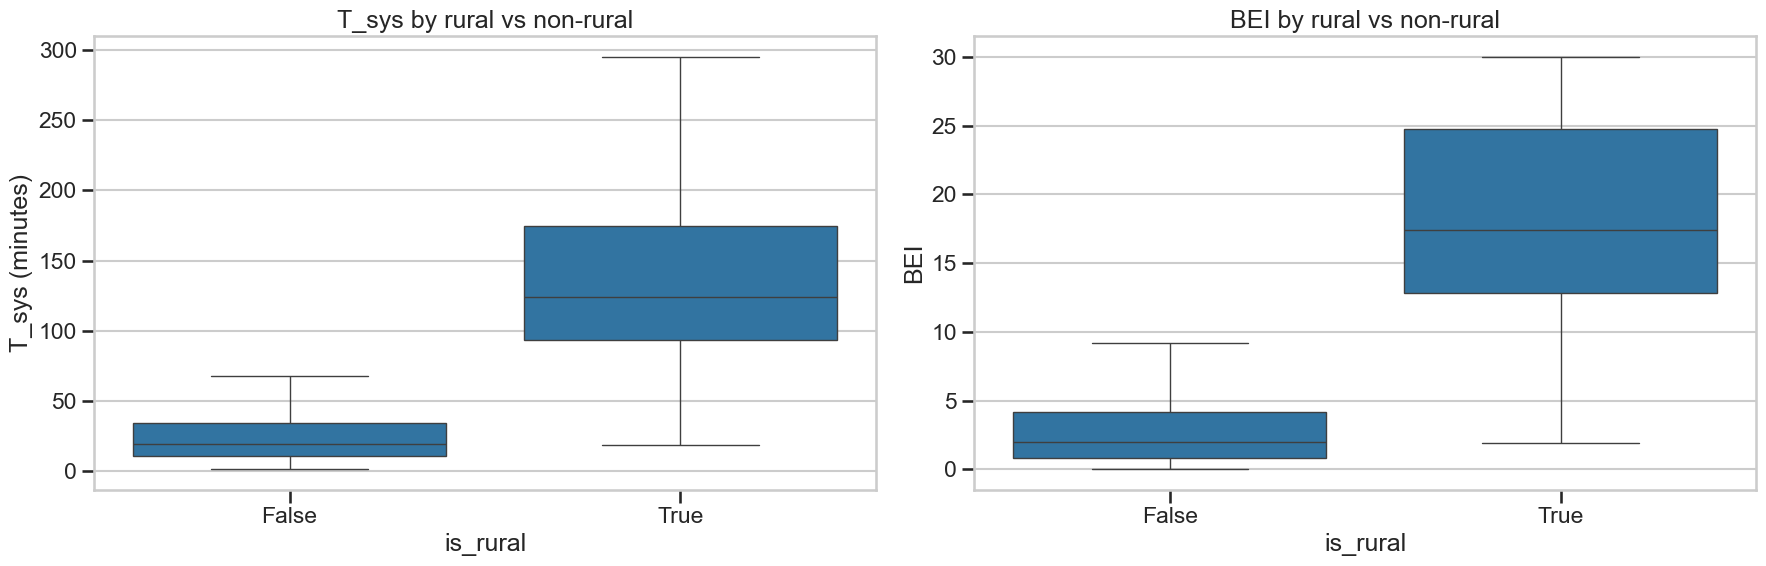

In [18]:
if "is_rural" in mn.columns:
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    sns.boxplot(
        data=mn,
        x="is_rural",
        y="t_sys",
        showfliers=False,
        ax=ax[0],
    )
    ax[0].set_title("T_sys by rural vs non-rural")
    ax[0].set_xlabel("is_rural")
    ax[0].set_ylabel("T_sys (minutes)")

    sns.boxplot(
        data=mn,
        x="is_rural",
        y="bei",
        showfliers=False,
        ax=ax[1],
    )
    ax[1].set_title("BEI by rural vs non-rural")
    ax[1].set_xlabel("is_rural")
    ax[1].set_ylabel("BEI")

    plt.tight_layout()
    plt.show()

    fig.savefig(FIG_DIR / "mn_rural_vs_urban.png", dpi=200, bbox_inches="tight")
else:
    print("Column 'is_rural' not found; skipping rural/urban plots.")

Has centroid columns: True


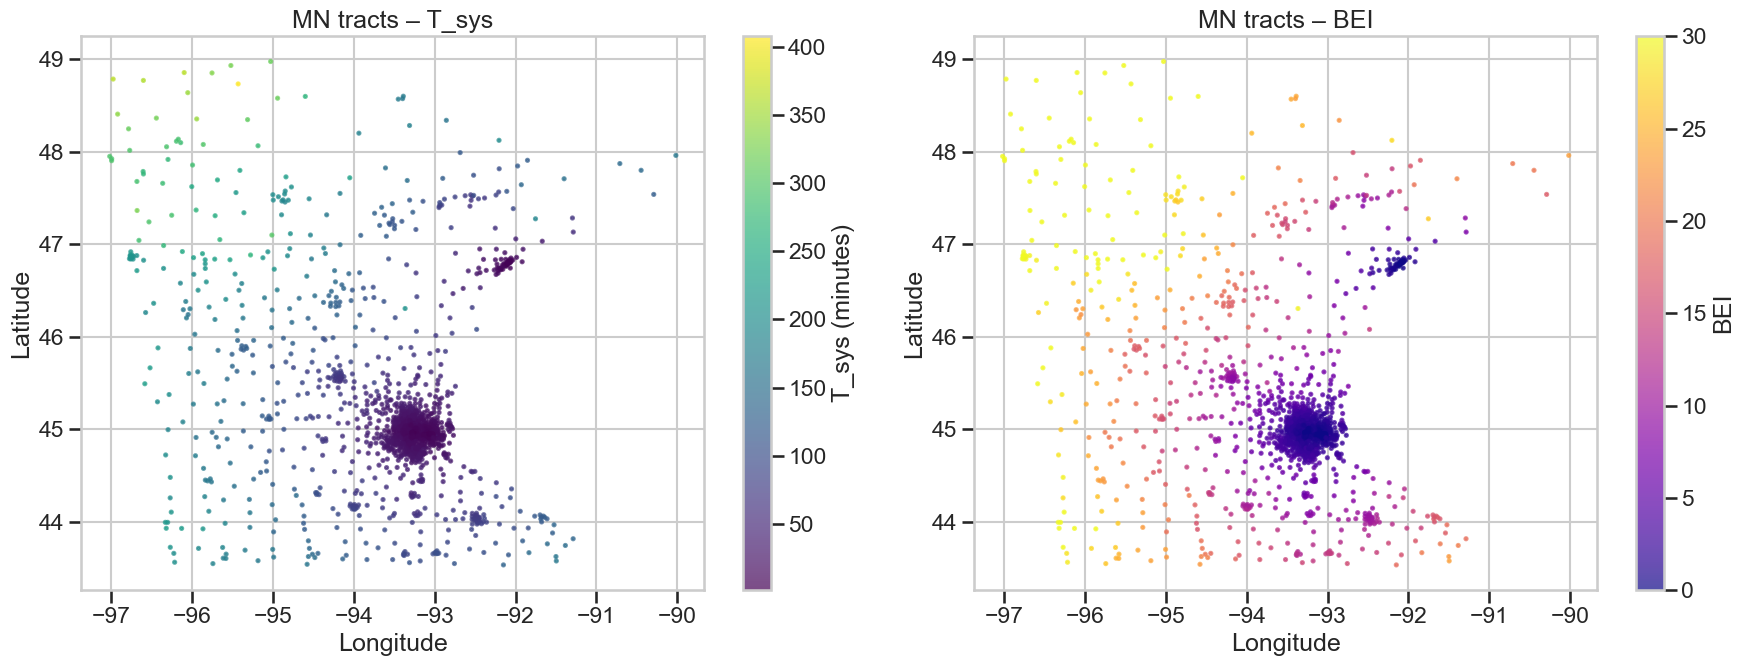

In [19]:
has_geo = {"centroid_lat", "centroid_lon"}.issubset(mn.columns)
print("Has centroid columns:", has_geo)

if has_geo:
    fig, ax = plt.subplots(1, 2, figsize=(18, 7))

    sc1 = ax[0].scatter(
        mn["centroid_lon"],
        mn["centroid_lat"],
        c=mn["t_sys"],
        cmap="viridis",
        s=5,
        alpha=0.7,
    )
    ax[0].set_title("MN tracts – T_sys")
    ax[0].set_xlabel("Longitude")
    ax[0].set_ylabel("Latitude")
    plt.colorbar(sc1, ax=ax[0], label="T_sys (minutes)")

    sc2 = ax[1].scatter(
        mn["centroid_lon"],
        mn["centroid_lat"],
        c=mn["bei"],
        cmap="plasma",
        s=5,
        alpha=0.7,
    )
    ax[1].set_title("MN tracts – BEI")
    ax[1].set_xlabel("Longitude")
    ax[1].set_ylabel("Latitude")
    plt.colorbar(sc2, ax=ax[1], label="BEI")

    plt.tight_layout()
    plt.show()

    fig.savefig(FIG_DIR / "mn_centroid_scatter_tsys_bei.png", dpi=200, bbox_inches="tight")
else:
    print("No centroid_lat / centroid_lon columns; skipping map-style scatter plots.")

In [22]:
# Debug BEI: inspect top tracts by BEI for sanity

# Choose a rich set of columns, but only keep those that actually exist
candidate_cols = [
    # Location / ID context
    "GEOID", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD",
    "county_name", "tract_name", "state_fips", "county_fips",
    "centroid_lat", "centroid_lon",
    # Access and BEI metrics
    "t_dir", "t_stab", "t_trans", "t_sys",
    "t_dir_air", "t_sys_air",  # air times if present
    "bei", "bei_percentile", "t_score", "s_score", "p_score", "c_score",
    # Demographics
    "total_pop", "child_pop", "is_rural",
    # Nearest-hospital context if present
    "nearest_definitive_aha_id", "nearest_definitive_name", "nearest_definitive_time_min",
    "nearest_stab_aha_id", "nearest_stab_name", "nearest_stab_time_min",
]

existing_cols = [c for c in candidate_cols if c in mn.columns]
print("Debug BEI – using columns:", existing_cols)

# Sort from highest BEI to lowest and show top N
N = 100
mn_sorted = mn.sort_values("bei", ascending=False).reset_index(drop=True)
mn_debug = mn_sorted[existing_cols].head(N)

mn_debug.style.format(precision=2)

Debug BEI – using columns: ['GEOID', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'NAME', 'NAMELSAD', 'centroid_lat', 'centroid_lon', 't_dir', 't_stab', 't_trans', 't_sys', 'bei', 'bei_percentile', 't_score', 'total_pop', 'child_pop', 'is_rural']


,GEOID,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,centroid_lat,centroid_lon,t_dir,t_stab,t_trans,t_sys,bei,bei_percentile,t_score,total_pop,child_pop,is_rural
0,27113090300,27,113,090300,903,Census Tract 903,48.05,-96.32,292.98,265.12,603.10,292.98,30.00,97.51,1.00,2182,552,True
1,27113090400,27,113,090400,904,Census Tract 904,48.11,-96.19,287.67,259.80,592.47,287.67,30.00,97.51,1.00,3181,578,True
2,27061480102,27,061,480102,4801.02,Census Tract 4801.02,47.72,-94.05,232.48,231.98,509.47,232.48,30.00,97.51,1.00,1340,225,True
3,27027030108,27,027,030108,301.08,Census Tract 301.08,46.84,-96.76,211.13,158.77,414.90,211.13,30.00,97.51,1.00,5564,1841,False
4,27069090100,27,069,090100,901,Census Tract 901,48.77,-96.60,359.40,331.55,735.95,359.40,30.00,97.51,1.00,2357,470,True
5,27113090200,27,113,090200,902,Census Tract 902,48.14,-96.17,288.88,261.02,594.90,288.88,30.00,97.51,1.00,2366,538,True
6,27027030110,27,027,030110,301.10,Census Tract 301.10,46.72,-96.68,222.83,170.48,438.32,222.83,30.00,97.51,1.00,5916,1852,False
7,27069090200,27,069,090200,902,Census Tract 902,48.78,-96.98,365.75,308.58,719.33,365.75,30.00,97.51,1.00,1834,441,True
8,27005450800,27,005,450800,4508,Census Tract 4508,46.86,-95.98,232.08,153.97,431.05,232.08,30.00,97.51,1.00,2435,539,True
9,27119020800,27,119,020800,208,Census Tract 208,47.66,-96.36,280.83,252.97,578.80,280.83,30.00,97.51,1.00,2119,523,True


In [ ]:
# Load MN facilities for mapping (via pipeline)
import sys

# Ensure src/ is on the path so we can import pipeline
src_path = REPO_ROOT / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from pipeline.run_valhalla_matrix import build_inputs

tracts_all, facilities_all = build_inputs()

# Subset facilities to Minnesota only (STATE == 'MN' or state_fips == '27' if present)
fac = facilities_all.copy()
if "STATE" in fac.columns:
    is_mn_abbr = fac["STATE"].astype(str).str.upper() == "MN"
else:
    is_mn_abbr = pd.Series(False, index=fac.index)
if "state_fips" in fac.columns:
    is_mn_fips = fac["state_fips"].astype(str).str.zfill(2) == "27"
else:
    is_mn_fips = pd.Series(False, index=fac.index)

fac_mn = fac[is_mn_abbr | is_mn_fips].copy()

print("MN facilities for mapping:", fac_mn.shape)
fac_mn.head()

In [ ]:
# Interactive folium map: MN tracts (centroids) + hospital locations
import folium
from branca.colormap import linear

# If ipywidgets is installed, we'll use it; otherwise we fall back to a simple call
try:
    from ipywidgets import interact, FloatRangeSlider, Dropdown
    from IPython.display import display
    HAVE_WIDGETS = True
except ImportError:
    from IPython.display import display
    HAVE_WIDGETS = False

# Ensure we have MN facilities in this cell (in case the previous cell wasn't run)
if "fac_mn" not in globals():
    import sys
    src_path = REPO_ROOT / "src"
    if src_path.is_dir() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))
    from pipeline.run_valhalla_matrix import build_inputs

    tracts_all, facilities_all = build_inputs()
    fac = facilities_all.copy()
    if "STATE" in fac.columns:
        is_mn_abbr = fac["STATE"].astype(str).str.upper() == "MN"
    else:
        is_mn_abbr = pd.Series(False, index=fac.index)
    if "state_fips" in fac.columns:
        is_mn_fips = fac["state_fips"].astype(str).str.zfill(2) == "27"
    else:
        is_mn_fips = pd.Series(False, index=fac.index)
    fac_mn = fac[is_mn_abbr | is_mn_fips].copy()

# Determine hospital name / ID columns if available
hosp_name_col = None
for c in ["FACILITY_NAME", "NAME", "Hospital_Name", "hospital_name"]:
    if c in fac_mn.columns:
        hosp_name_col = c
        break
hosp_id_col = None
for c in ["AHA_ID", "aha_id", "ID"]:
    if c in fac_mn.columns:
        hosp_id_col = c
        break


def make_mn_map(bei_percentile_range=(0.0, 100.0), rural_filter="All"):
    """Build an interactive folium map with filters on BEI percentile and rural/urban."""
    df = mn.copy()

    # Filter by BEI percentile
    low, high = bei_percentile_range
    df = df[(df["bei_percentile"] >= low) & (df["bei_percentile"] <= high)]

    # Optional rural/urban filter
    if rural_filter in {"Rural only", "Urban only"} and "is_rural" in df.columns:
        want_rural = rural_filter == "Rural only"
        df = df[df["is_rural"] == want_rural]

    if df.empty:
        print("No tracts match the current filters.")
        return

    # Center map on filtered tracts
    lat0 = df["centroid_lat"].mean()
    lon0 = df["centroid_lon"].mean()

    m = folium.Map(location=[lat0, lon0], zoom_start=6, tiles="CartoDB positron")

    # Colormap for BEI
    bei_min, bei_max = df["bei"].min(), df["bei"].max()
    cmap = linear.OrRd_09.scale(bei_min, bei_max)
    cmap.caption = "BEI (MN tracts)"

    # Layer for tracts
    tract_layer = folium.FeatureGroup(name="Tract centroids (BEI)", show=True)

    for _, row in df.iterrows():
        color = cmap(row["bei"]) if np.isfinite(row["bei"]) else "#cccccc"
        popup_items = [
            f"GEOID: {row.get('GEOID', '')}",
            f"Name: {row.get('NAMELSAD', row.get('NAME', ''))}",
            f"T_sys (min): {row.get('t_sys', np.nan):.1f}",
            f"BEI: {row.get('bei', np.nan):.2f}",
            f"BEI pct: {row.get('bei_percentile', np.nan):.1f}",
            f"Total pop: {row.get('total_pop', np.nan):,.0f}",
            f"Rural: {row.get('is_rural', '')}",
        ]
        popup = folium.Popup("<br>".join(popup_items), max_width=300)
        folium.CircleMarker(
            location=[row["centroid_lat"], row["centroid_lon"]],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.8,
            popup=popup,
        ).add_to(tract_layer)

    tract_layer.add_to(m)

    # Layer for hospitals
    hosp_layer = folium.FeatureGroup(name="Hospitals", show=True)

    for _, row in fac_mn.dropna(subset=["latitude", "longitude"]).iterrows():
        name = row[hosp_name_col] if hosp_name_col else "Hospital"
        hid = row[hosp_id_col] if hosp_id_col else ""
        popup_lines = [
            f"Name: {name}",
            f"ID: {hid}",
            f"Lat/Lon: {row['latitude']:.4f}, {row['longitude']:.4f}",
        ]
        popup = folium.Popup("<br>".join(popup_lines), max_width=300)
        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            popup=popup,
            icon=folium.Icon(color="red", icon="plus", prefix="fa"),
        ).add_to(hosp_layer)

    hosp_layer.add_to(m)

    # Add colormap and layer control
    cmap.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    display(m)


if HAVE_WIDGETS:
    # Interactive controls with ipywidgets
    bei_slider = FloatRangeSlider(
        value=[0.0, 100.0],
        min=0.0,
        max=100.0,
        step=1.0,
        description="BEI pct:",
        continuous_update=False,
        layout={"width": "60%"},
    )

    rural_dropdown = Dropdown(
        options=["All", "Rural only", "Urban only"],
        value="All",
        description="Area:",
    )

    interact(make_mn_map, bei_percentile_range=bei_slider, rural_filter=rural_dropdown);
else:
    # Fallback: just render a static map for a high-BEI slice (e.g. 80–100 pct)
    print("ipywidgets not installed; showing a static high-BEI map (80–100 pct).")
    make_mn_map(bei_percentile_range=(80.0, 100.0), rural_filter="All")

Ingest:   0%|          | 0/4 [00:00<?, ?step/s]

Using cached geocode results: C:\Users\tngzj\OneDrive\Desktop\Heatmap_Hackathon\Data\output\tables\GeocodeResults.csv
  -> 635/635 facilities have coordinates after CSV merge
  -> 557 facilities have tract_geoid after CSV merge
  -> Running TIGER tract assignment for 78 remaining facilities...
  TIGER: loading 51 tract shapefiles...


TIGER load:   0%|          | 0/51 [00:00<?, ?shp/s]

  TIGER: assigned tract for 78 facilities (point-in-polygon)


Augment:   0%|          | 0/4 [00:00<?, ?step/s]

Augment TIGER:   0%|          | 0/51 [00:00<?, ?shp/s]

Origins (tracts): 84,415  |  Destinations (facilities): 635


### Notes on interactive map

- Circles show **tract centroids**, colored by **BEI** (higher = worse access in this MVP).
- Red markers show **MN hospital locations** from the NIRD-derived facility table.
- Use the **BEI percentile slider** to focus on the highest-BEI tracts (e.g. 80–100).
- Use the **Area dropdown** to view all tracts, only rural, or only urban (if `is_rural` is available).